# Postprocessing after training

Import custom functions and define paths to datadirectories.

In [1]:
%load_ext autoreload
%autoreload 2

In [7]:
import os
import numpy as np
import sys
from pathlib import Path
scripts_dir = Path.cwd().parents[1]
if str(scripts_dir) not in sys.path:
    sys.path.insert(0, str(scripts_dir))
from gan_pipeline.core import custom_plots as custom_plots
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from postprocessing import PostProcessing, WellMismatch
custom_plots.apply_custom_plotting_flavor()

well_data_path = Path(r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\datasets\well_data\Well_data.xlsx")
gan_data_dir = Path(r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\outputs\post_editing\editing\realizations\*.npy")
real_data_dir = Path(r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\datasets\training\setting_1_nexus_1000_samples_ntg_0.67_chdepth_6_isbx_100\samples\facies\*.npy")
output_dir = Path(r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_editing_plots")
os.makedirs(output_dir,exist_ok=True)

## Inspect Loss history

Found 1 history files: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\outputs\post_editing\editing


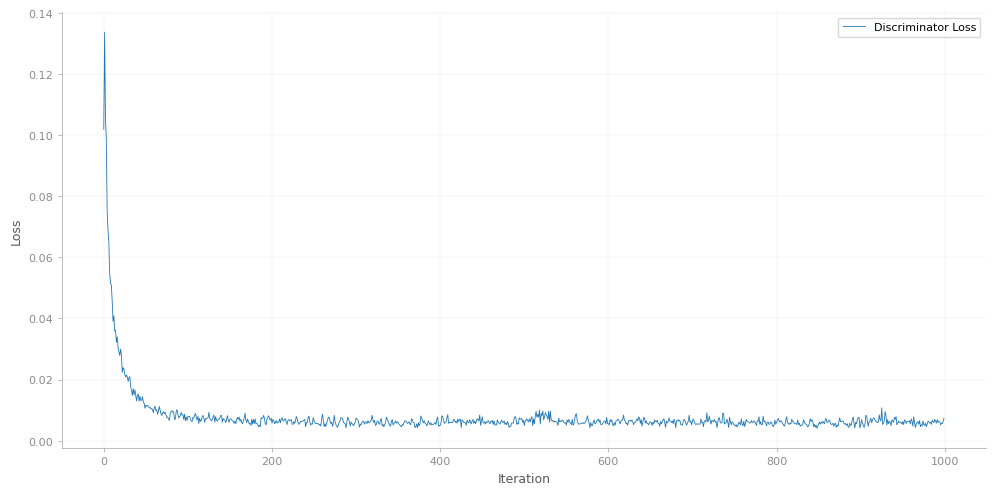

In [8]:
history_dir = gan_data_dir.parent.parent

try:
    history_files = list(history_dir.glob("*.csv"))
    print(f"Found {len(history_files)} history files: {history_dir}")
except Exception as e:
    print(f"Error accessing history directory: {history_dir}")
    print(e)

Loss = pd.read_csv(history_files[0])
step = np.arange(len(Loss))

plt.figure(figsize=(10, 5))
plt.grid()
plt.plot(step, Loss['loss'], label='Discriminator Loss') 
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

## Initialize postprocessing class

In [9]:
Postproc = PostProcessing(output_dir=output_dir,real_path=real_data_dir,gan_path=gan_data_dir)

Loading GAN samples (limit: 100)...
Loaded 100 GAN samples into memory.
Loading Real samples (limit: 100)...
Loaded 0 real samples into memory.

--- Generating GAN Normalized Entropy Matrices ---
Real Dataset Baseline Proportions: [0.0, 0.0, 0.0]
Target Baseline H_max:  -0.0000 bits


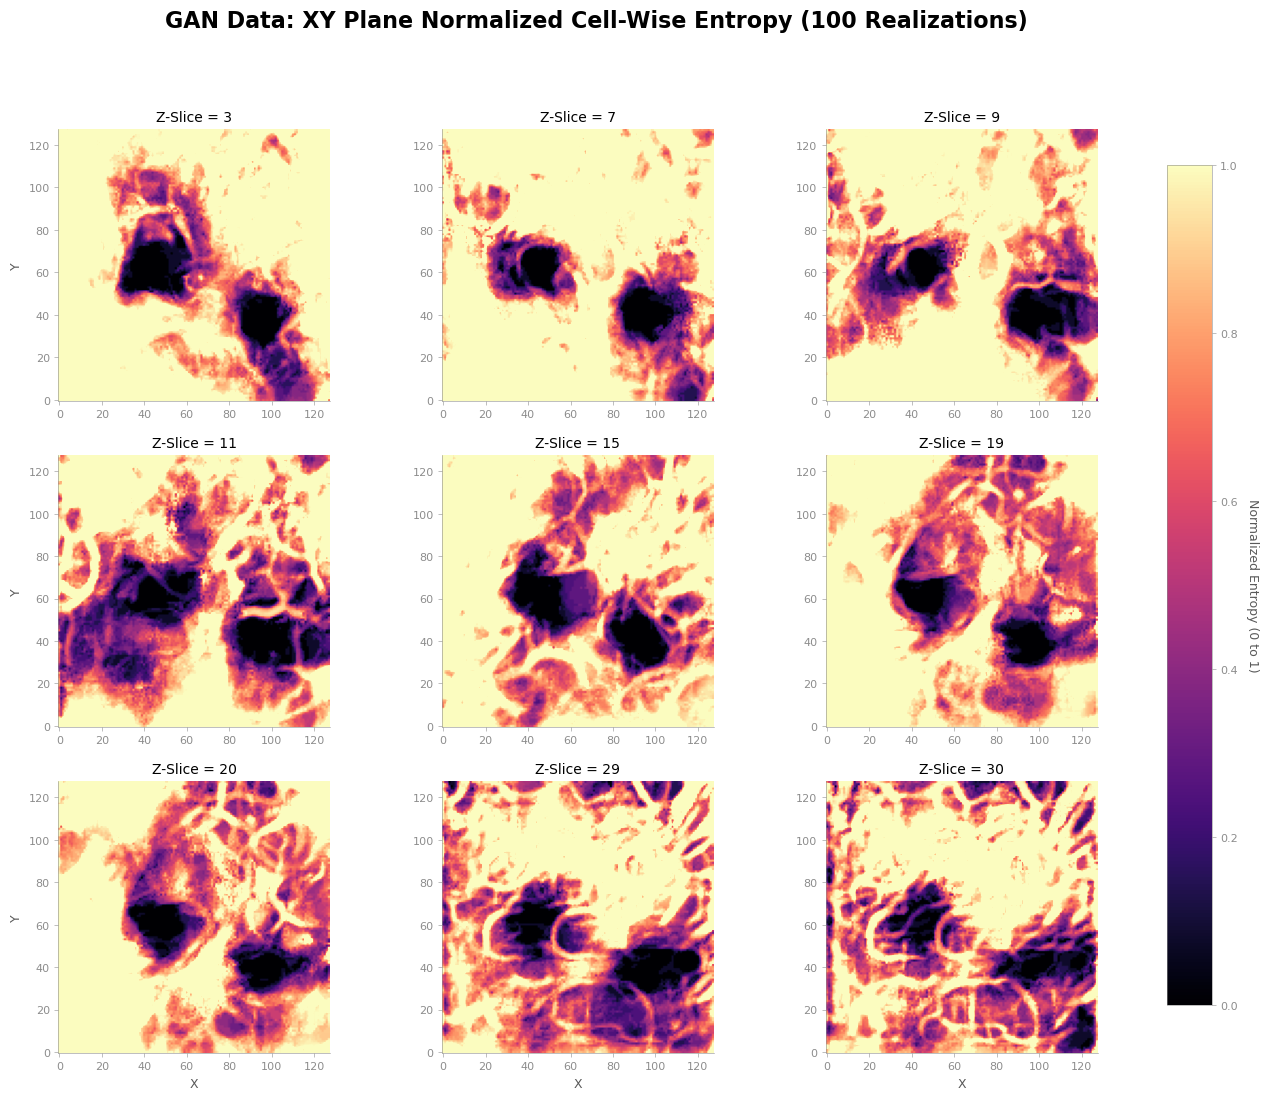

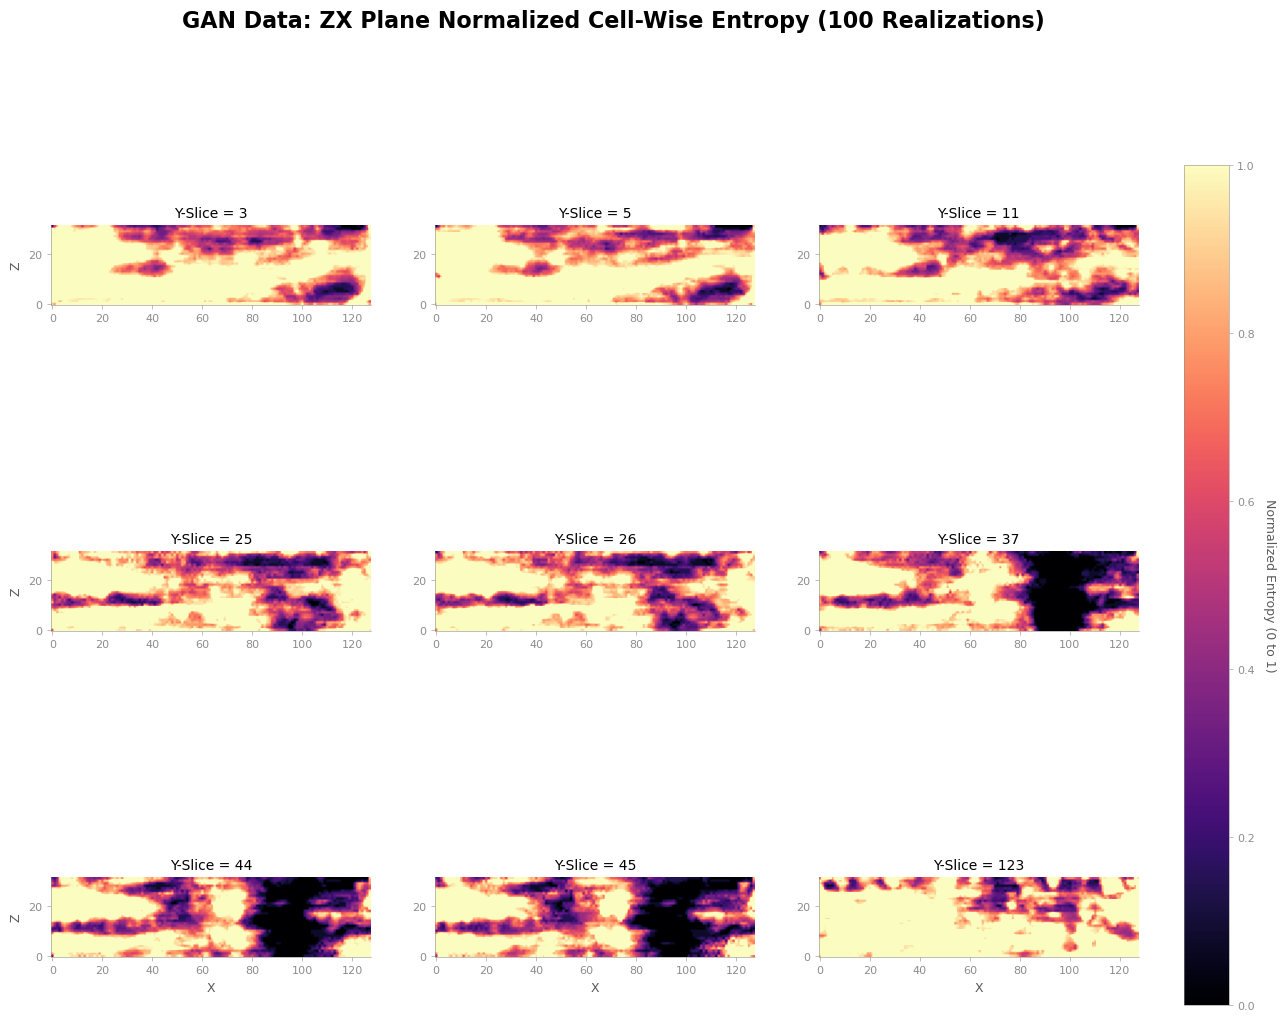

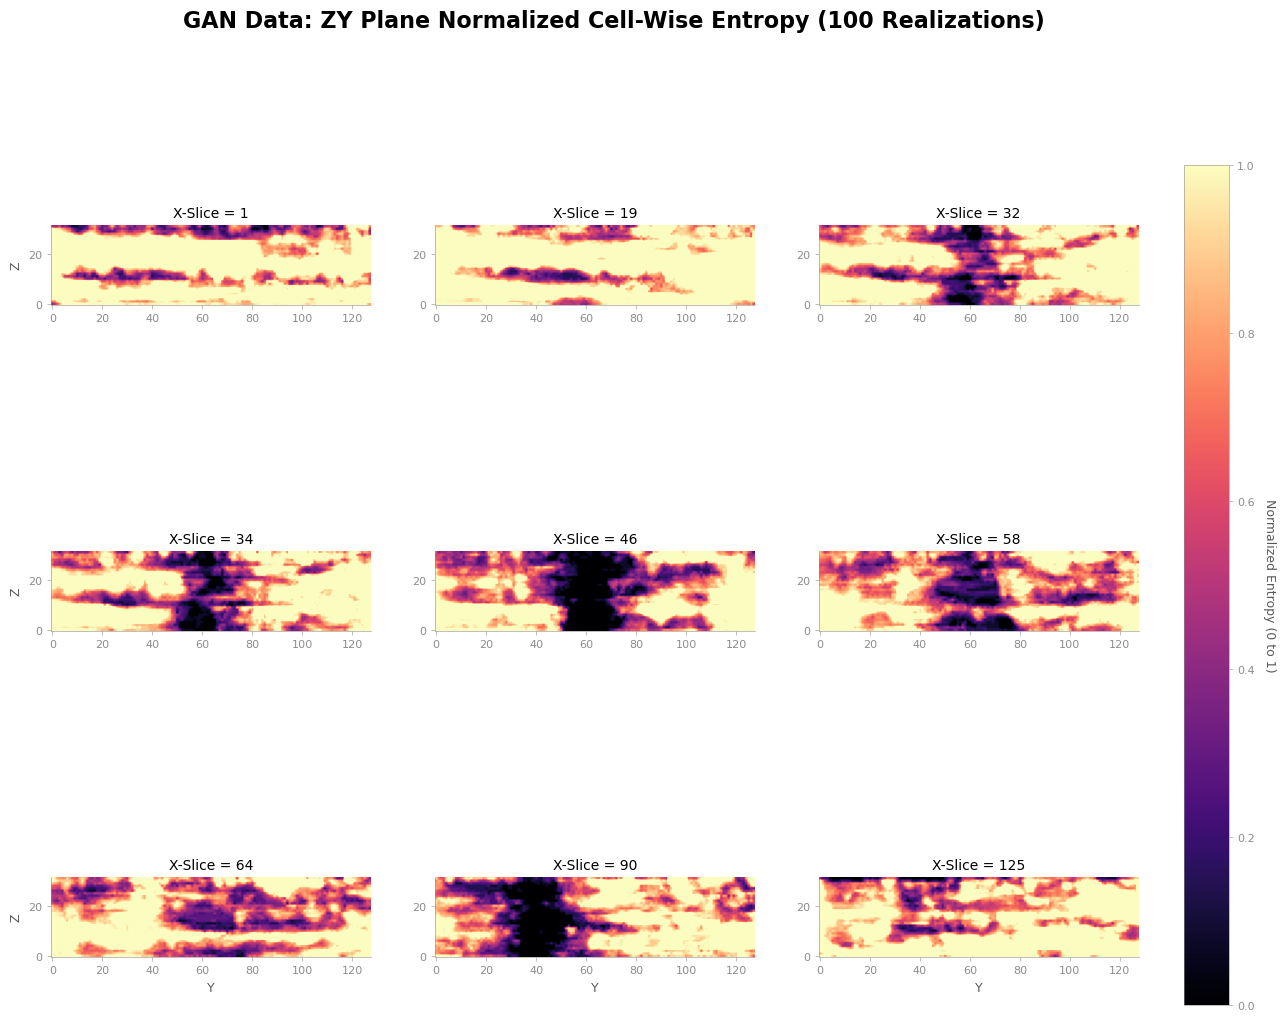

In [5]:
Postproc.plot_entropy()

In [10]:
well_validator = WellMismatch(gan_data_dir,well_data_path)

Loaded 64 well conditioning points.


In [11]:
well_validator.compute_mismatch()


--- Well Data Mismatch ---
Evaluated 100 realizations.
Average Macro F1 Score: 1.0000


,Realization,Macro_F1_Score
0,realization_1.npy,1.0
1,realization_10.npy,1.0
2,realization_100.npy,1.0
3,realization_11.npy,1.0
4,realization_12.npy,1.0
...,...,...
95,realization_95.npy,1.0
96,realization_96.npy,1.0
97,realization_97.npy,1.0
98,realization_98.npy,1.0


Loading GAN samples (limit: 100)...
Loaded 100 GAN samples into memory.

--- Generating Facies Distribution (Mode: GAN) ---


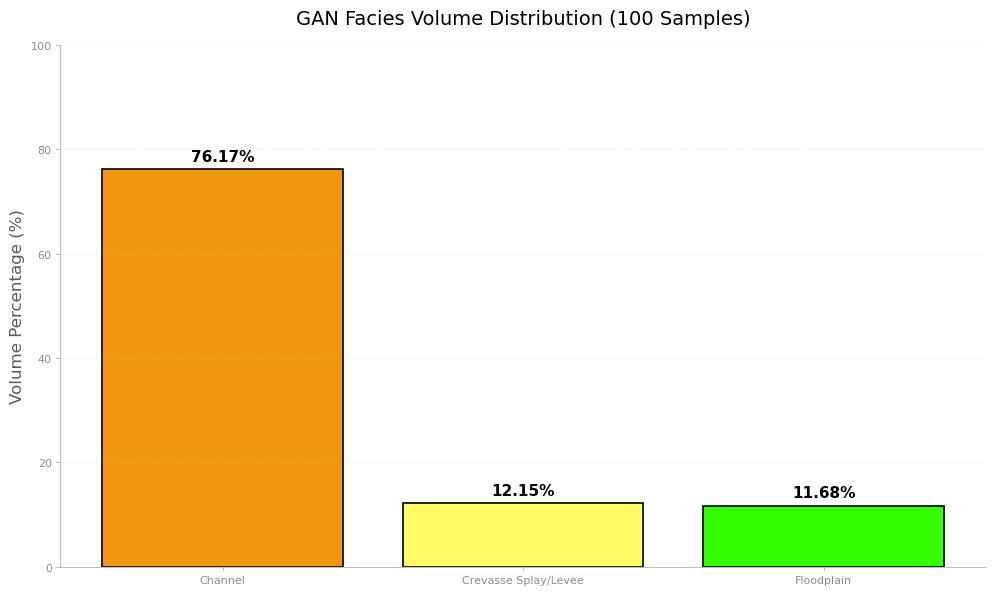

In [14]:
Postproc = PostProcessing(output_dir=output_dir,real_path=real_data_dir,gan_path=gan_data_dir)
Postproc.plot_facies_percentages()